In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1. Load data
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')

In [3]:
df.head()

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [4]:
# Setup Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [5]:
# 2. Split and Scale (Mandatory for ANN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# 3. Initialize ANN (Multi-Layer Perceptron)
# We use two hidden layers to capture complex interactions
ann_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), # Increased hidden layers and neurons
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

In [23]:
# 4. Train the model
ann_model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=2000, random_state=42)

In [24]:
# 5. Predict and Evaluate
y_pred = ann_model.predict(X_test_scaled)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} MPa")

R2 Score: 0.9490
RMSE:     32.67 MPa


In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE:      {mae:.2f} MPa")

MAE:      26.17 MPa


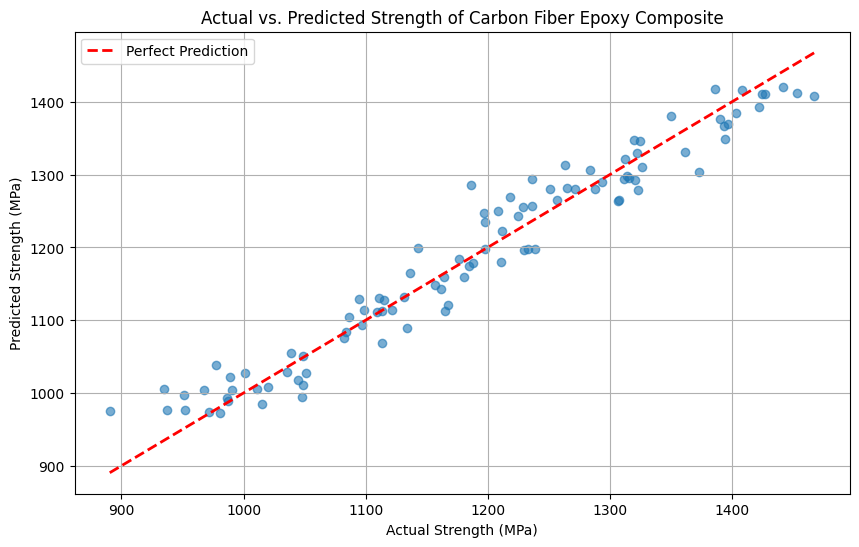

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Actual vs. Predicted Strength of Carbon Fiber Epoxy Composite')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
result = permutation_importance(ann_model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Store results in a DataFrame
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

# Sort by importance
feature_importances = feature_importances.sort_values(by='importance_mean', ascending=False)

print("Feature Importances (Permutation Importance):")
print(feature_importances)

Feature Importances (Permutation Importance):
                 feature  importance_mean  importance_std
1   epoxy_resin_fraction         0.850711        0.098481
0  carbon_fiber_fraction         0.210482        0.023441
2        volume_fraction         0.028802        0.005336


/tmp/ipykernel_1232/2568938877.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_mean', y='feature', data=feature_importances, palette='viridis')


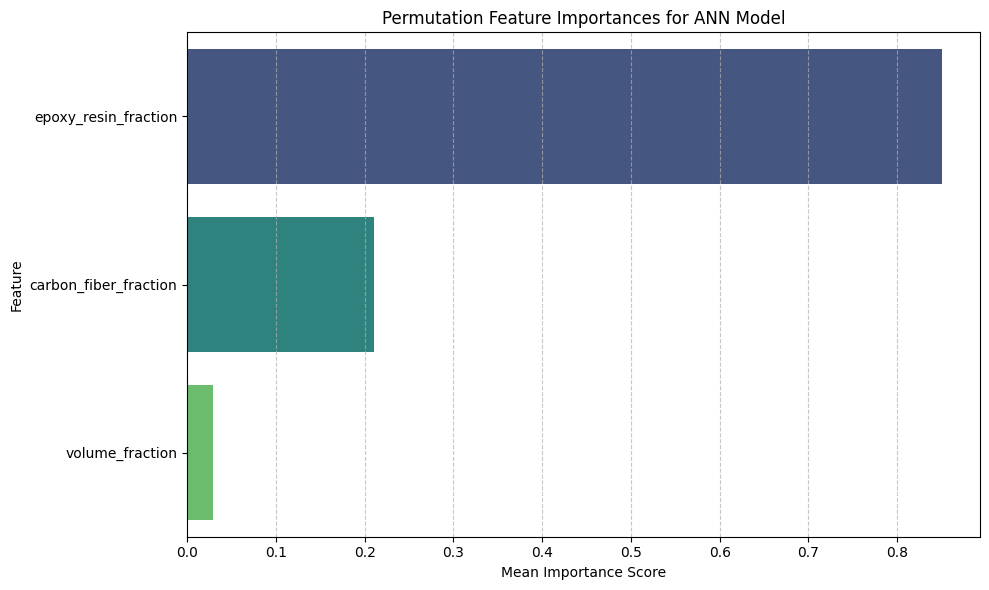

In [29]:
import seaborn as sns

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=feature_importances, palette='viridis')
plt.xlabel('Mean Importance Score')
plt.ylabel('Feature')
plt.title('Permutation Feature Importances for ANN Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sensitivity Analysis on Epoxy Resin Fraction

To understand how the 'epoxy_resin_fraction' specifically influences the predicted 'strength_MPa', we will perform a sensitivity analysis. We will vary the 'epoxy_resin_fraction' across its observed range, while keeping the other input features ('carbon_fiber_fraction' and 'volume_fraction') constant at their average values. This allows us to isolate the effect of the epoxy resin fraction on the model's output.

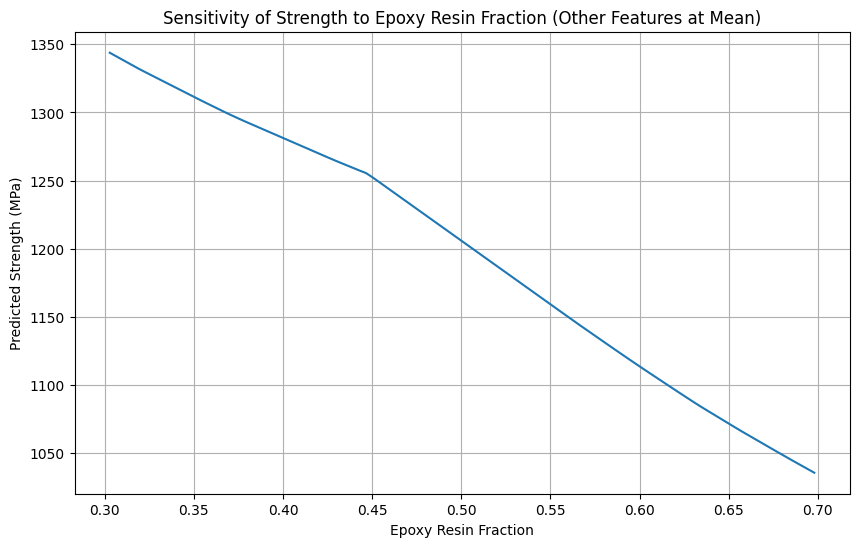

In [30]:
# Get mean values for other features
mean_carbon_fiber_fraction = X['carbon_fiber_fraction'].mean()
mean_volume_fraction = X['volume_fraction'].mean()

# Create a range for epoxy_resin_fraction
epoxy_resin_range = np.linspace(X['epoxy_resin_fraction'].min(), X['epoxy_resin_fraction'].max(), 100)

# Create a DataFrame for sensitivity analysis
sensitivity_df = pd.DataFrame({
    'carbon_fiber_fraction': [mean_carbon_fiber_fraction] * len(epoxy_resin_range),
    'epoxy_resin_fraction': epoxy_resin_range,
    'volume_fraction': [mean_volume_fraction] * len(epoxy_resin_range)
})

# Scale the sensitivity data using the *fitted* scaler
sensitivity_scaled = scaler.transform(sensitivity_df)

# Predict strength using the trained ANN model
predicted_strength_sensitivity = ann_model.predict(sensitivity_scaled)

# Add predictions to the DataFrame
sensitivity_df['predicted_strength'] = predicted_strength_sensitivity

# Plot the sensitivity analysis results
plt.figure(figsize=(10, 6))
sns.lineplot(x='epoxy_resin_fraction', y='predicted_strength', data=sensitivity_df)
plt.xlabel('Epoxy Resin Fraction')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Sensitivity of Strength to Epoxy Resin Fraction (Other Features at Mean)')
plt.grid(True)
plt.show()